In [1]:
import torch
import torch.nn as nn

import numpy as np
import sys
import os
import torch

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa
from utils.bam import MultiBAMv4, SymbolClassifier

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\my_lora_utils.py


In [ ]:
sf = 9
bw = 125000
fs = 1000000
lora_init = LoRa(sf, bw)
input_row = 512
input_col = 33
second_layer = 1024
third_layer = 64

## ## Load BAM model and weight
BAM_layers = [input_col * input_row, second_layer, third_layer] # <-- must match training
multi_bam = MultiBAMv4(layers_dims=BAM_layers, eta=1e-5)
for i, bam in enumerate(multi_bam.bams):
    path = f"weight_{input_row*input_col}_{second_layer}_{third_layer}/weights_layer_{i}.npy"

    if os.path.isfile(path):
        w_np = np.load(path)
        bam.W = torch.tensor(w_np, dtype=torch.float32, device=bam.device)
        print(f"✅ Loaded layer {i} | shape {bam.W.shape}")
    else:
        print(f"⚠️ Missing file for layer {i}: {path}")

## Load Classifier
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_layers = [third_layer, 1024, int(2**sf)]
model = SymbolClassifier(class_layers).to(device)
model.load_state_dict(torch.load("symbol_classifier.pt", map_location=device))

model.eval()   # 🔴 VERY IMPORTANT

⚠️ Missing file for layer 0: weight_16896_1024_64/weights_layer_0.npy
⚠️ Missing file for layer 1: weight_16896_1024_64/weights_layer_1.npy


SymbolClassifier(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
  )
)

In [5]:
SNR_first = 10
SNR_last = -30
seed = None
if seed is not None:
    np.random.seed(seed)  # make noise reproducible
number_of_symbol_per_snr = 1000
data_final = {}

BATCH = 256

for snr in range(SNR_first, SNR_last, -1):
    data_final[snr] = {"correct": 0, "false": 0}

    batch_X = []
    batch_y = []

    with torch.no_grad():
        for _ in range(number_of_symbol_per_snr):

            r = np.random.randint(0, 512)

            x1 = lora_init.gen_symbol_fs(r, sf=sf, bw=bw, Fs=fs)
            x = lora_init.awgn_iq_with_seed(x1, snr, seed)

            input_spec = create_spectrogram_from_torch(x,sf,bw,fs,input_row,input_col,0,0,1,None)
            flat = input_spec.flatten().reshape(1, -1)
            out = multi_bam.compress(flat).squeeze()

            batch_X.append(out)
            batch_y.append(r)

            if len(batch_X) == BATCH:
                X = torch.tensor(batch_X, dtype=torch.float32).to(device)
                X = X / (torch.norm(X, dim=1, keepdim=True) + 1e-8)

                logits = model(X)
                preds = logits.argmax(dim=1).cpu().numpy()

                for p, gt in zip(preds, batch_y):
                    if p == gt:
                        data_final[snr]["correct"] += 1
                    else:
                        data_final[snr]["false"] += 1

                batch_X.clear()
                batch_y.clear()

    total = data_final[snr]["correct"] + data_final[snr]["false"]
    acc = data_final[snr]["correct"] / total
    print(f"SNR {snr} dB | Accuracy = {acc:.3f}")

print(data_final)
import json

with open("evaluation_results.json", "w") as f:
    json.dump(data_final, f, indent=4)



SNR 10 dB | Accuracy = 0.453
SNR 9 dB | Accuracy = 0.443
SNR 8 dB | Accuracy = 0.448
SNR 7 dB | Accuracy = 0.492
SNR 6 dB | Accuracy = 0.447
SNR 5 dB | Accuracy = 0.457
SNR 4 dB | Accuracy = 0.464
SNR 3 dB | Accuracy = 0.465
SNR 2 dB | Accuracy = 0.473
SNR 1 dB | Accuracy = 0.496
SNR 0 dB | Accuracy = 0.445
SNR -1 dB | Accuracy = 0.462
SNR -2 dB | Accuracy = 0.443
SNR -3 dB | Accuracy = 0.438
SNR -4 dB | Accuracy = 0.473
SNR -5 dB | Accuracy = 0.457
SNR -6 dB | Accuracy = 0.436
SNR -7 dB | Accuracy = 0.411
SNR -8 dB | Accuracy = 0.421
SNR -9 dB | Accuracy = 0.376
SNR -10 dB | Accuracy = 0.370
SNR -11 dB | Accuracy = 0.391
SNR -12 dB | Accuracy = 0.375
SNR -13 dB | Accuracy = 0.314
SNR -14 dB | Accuracy = 0.296
SNR -15 dB | Accuracy = 0.254
SNR -16 dB | Accuracy = 0.237
SNR -17 dB | Accuracy = 0.204
SNR -18 dB | Accuracy = 0.189
SNR -19 dB | Accuracy = 0.147
SNR -20 dB | Accuracy = 0.141
SNR -21 dB | Accuracy = 0.100
SNR -22 dB | Accuracy = 0.092
SNR -23 dB | Accuracy = 0.073
SNR -24 dB

{10: {'correct': 1336, 'false': 1480}, 9: {'correct': 1292, 'false': 1524}, 8: {'correct': 1332, 'false': 1484}, 7: {'correct': 1369, 'false': 1447}, 6: {'correct': 1336, 'false': 1480}, 5: {'correct': 1312, 'false': 1504}, 4: {'correct': 1316, 'false': 1500}, 3: {'correct': 1304, 'false': 1512}, 2: {'correct': 1299, 'false': 1517}, 1: {'correct': 1283, 'false': 1533}, 0: {'correct': 1277, 'false': 1539}, -1: {'correct': 1300, 'false': 1516}, -2: {'correct': 1297, 'false': 1519}, -3: {'correct': 1298, 'false': 1518}, -4: {'correct': 1235, 'false': 1581}, -5: {'correct': 1217, 'false': 1599}, -6: {'correct': 1220, 'false': 1596}, -7: {'correct': 1213, 'false': 1603}, -8: {'correct': 1163, 'false': 1653}, -9: {'correct': 1124, 'false': 1692}, -10: {'correct': 1049, 'false': 1767}, -11: {'correct': 1082, 'false': 1734}, -12: {'correct': 959, 'false': 1857}, -13: {'correct': 935, 'false': 1881}, -14: {'correct': 833, 'false': 1983}, -15: {'correct': 778, 'false': 2038}, -16: {'correct': 61

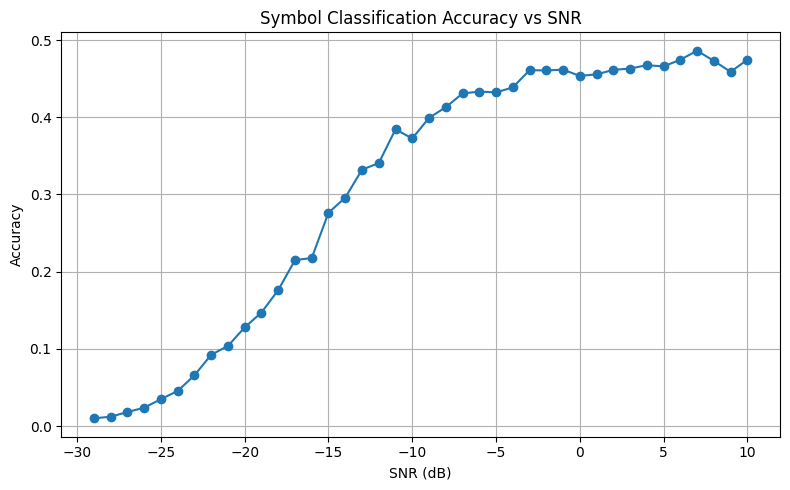

In [4]:
with open("evaluation_results.json", "r") as f:
    data_final = json.load(f)
# Convert SNR keys back to int
data_final = {int(k): v for k, v in data_final.items()}
print(data_final)
snrs = sorted(data_final.keys())
print(snrs)
accuracy = []

for snr in snrs:
    correct = data_final[snr]["correct"]
    total = correct + data_final[snr]["false"]
    accuracy.append(correct / total)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(snrs, accuracy, marker='o')
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Symbol Classification Accuracy vs SNR")
plt.grid(True)
plt.gca()
plt.tight_layout()
plt.show()